In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Data path from Tutorial 1
data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ"
dest_path = f"{data_path}/output"

# Input file from Tutorial 1
input_trace = f"{dest_path}/merged_traces.ecsv"

print(f"Input file: {input_trace}")
print(f"Output folder: {dest_path}")

Input file: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_cleaned.ecsv
Output folder: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output


# Tutorial 2: Quality Control Analysis of Merged Chromatin Traces

Before filtering or downstream analysis, assess your data quality through comprehensive statistical analysis.

`trace_analyzer` computes:
- **Trace Statistics**: Distribution of barcode counts per trace
- **Barcode Detection**: How reliably each barcode is detected (bootstrap analysis)
- **Neighbor Distances**: Spacing between consecutive barcodes (ΔX, ΔY, ΔZ)
- **Barcode Frequencies**: How often individual barcodes appear
- **Spatial KDE Projections**: Density heatmaps showing where spots are located in X, Y, Z

These metrics guide filtering decisions in Tutorial 3.

## Step 1: Run Quality Control Analysis

In [10]:
# Run trace_analyzer for detailed quality metrics
!trace_analyzer --input {input_trace}

------- Running trace_analyzer.py --------
Analyze chromatin trace files.


1 trace files to process= /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_cleaned.ecsv
$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_cleaned.ecsv
> Analyzing traces for /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_cleaned.ecsv
$ Number of spots in trace file: 326271
$ Calculating overall barcode detection across 5148 traces...
$ Exporting barcode detection plot to: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_cleaned_barcode_detection.png
$ Saved neighbor distances plot: /mnt/grey/DATA/users/zidoum/traceraptops/Boettiger_Forelimb_small/4DNFI2BK5CFZ/output/merged_traces_filtered_cleaned_first_neig

## Step 2: Barcode Detection Efficiency

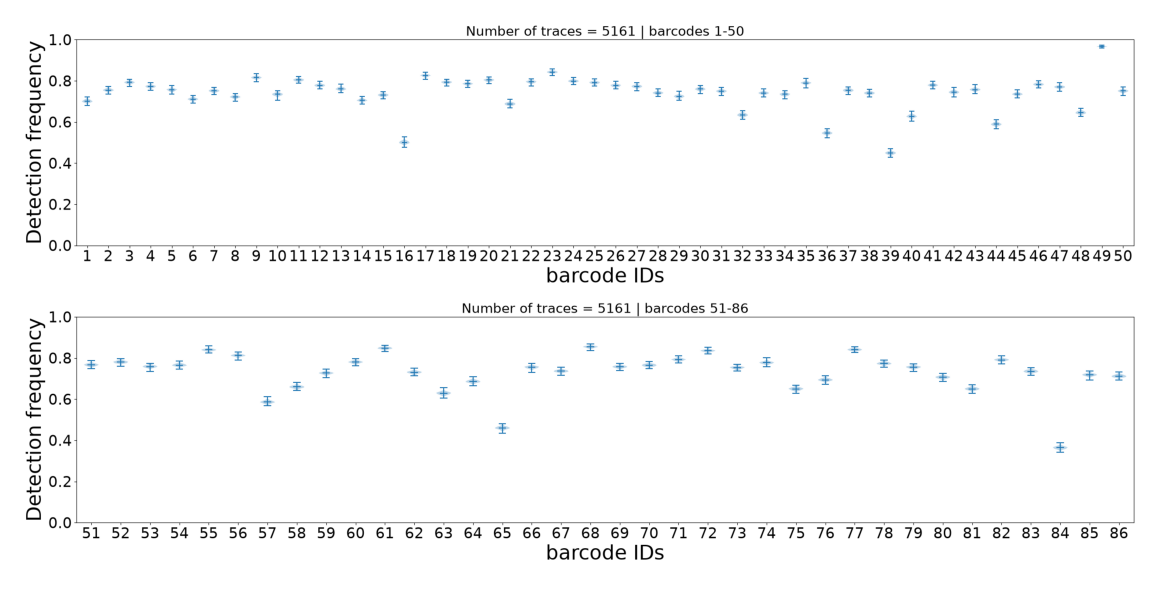

In [3]:
plot_file = f"{dest_path}/merged_traces_barcode_detection.png"
img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()


This plot shows how often each individual barcode is detected across all traces. Each barcode is represented by a **violin plot** (bootstrap distribution with 1000 iterations), which shows:

- **Height of the violin**: Range of detection frequencies (0-100%)
- **Median line**: Most common detection frequency
- **Shape**: Distribution shape indicates consistency

**Interpretation:**
- Narrow violin = reliable barcode (consistent detection)
- Wide violin = unreliable barcode (variable detection)
- Barcodes with very low median detection may be candidates for `--remove_barcode` in Tutorial 3

## Step 3: Neighbor Distance Distribution

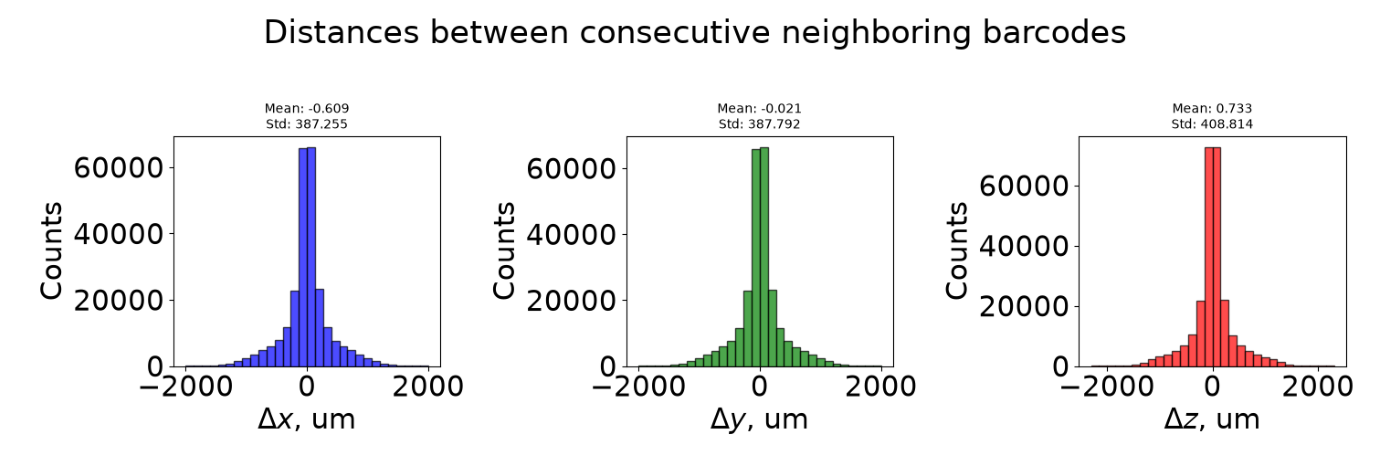

In [4]:
plot_file = f"{dest_path}/merged_traces_first_neighbor_distances.png"
img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

This plot shows distances between **consecutive barcodes** (barcode_i+1 - barcode_i) for all traces. Three distributions are shown:

- **ΔX (blue)**: Distance in X dimension
- **ΔY (green)**: Distance in Y dimension
- **ΔZ (red)**: Distance in Z dimension (optical axis)

**Interpretation:**
- Bell-shaped, centered near 0 = uniform spacing between barcodes (expected)
- Large spread or multiple peaks = inconsistent spacing or detection issues
- ΔZ much larger than ΔX/ΔY = potential focusing problems

## Step 4: Barcode Repetition Patterns

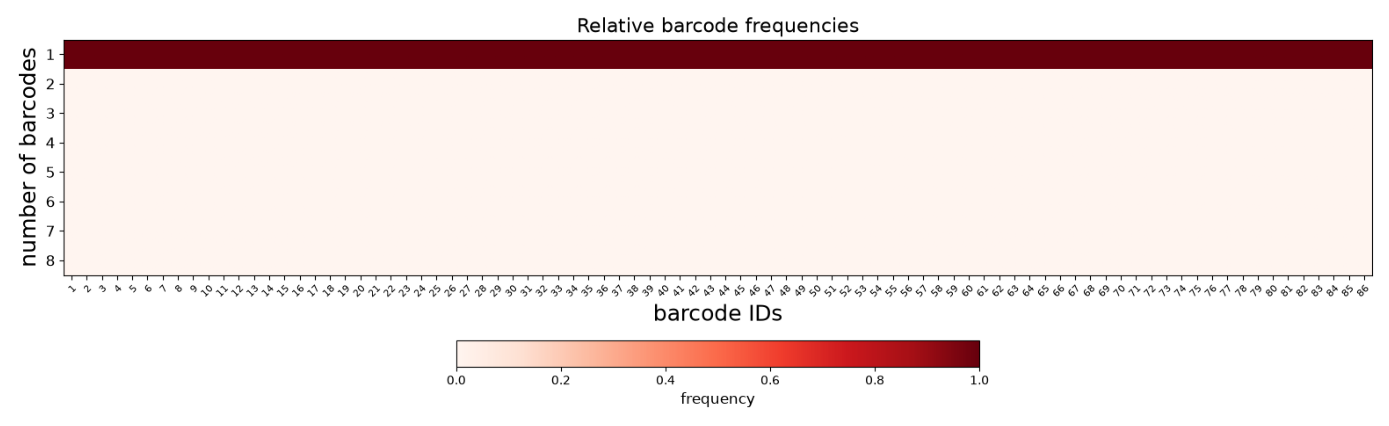

In [5]:
plot_file = f"{dest_path}/merged_traces_relative_barcode_frequencies.png"
img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

This plot shows how often individual barcodes are **repeated** within single traces:

- **Y-axis**: Number of times each barcode appears per trace (repetition count)
- Near 1 = barcode appears once per trace (ideal)
- Toward 2+ = barcode frequently duplicated (optical artifacts or detection noise)

Duplicated barcodes are handled in Tutorial 4 (`--clean_spots`).

## Step 5: Trace Statistics Summary

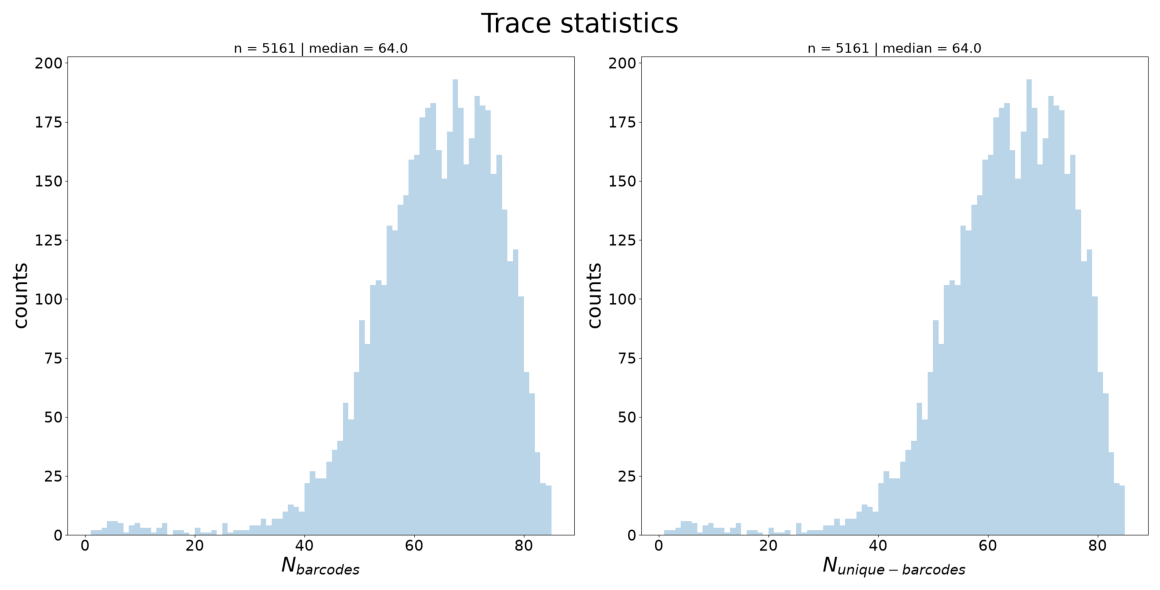

In [6]:
plot_file = f"{dest_path}/merged_traces_trace_statistics.png"
img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

Three distributions across all traces:

- **N_barcodes** (left): Number of barcode detections per trace
- **N_unique_barcodes** (middle): Number of distinct barcodes per trace

**Interpretation:**
- N_barcodes median indicates trace completeness → guides `--n_barcodes` threshold in Tutorial 3

## Step 6: Spatial Distribution (KDE Projections)

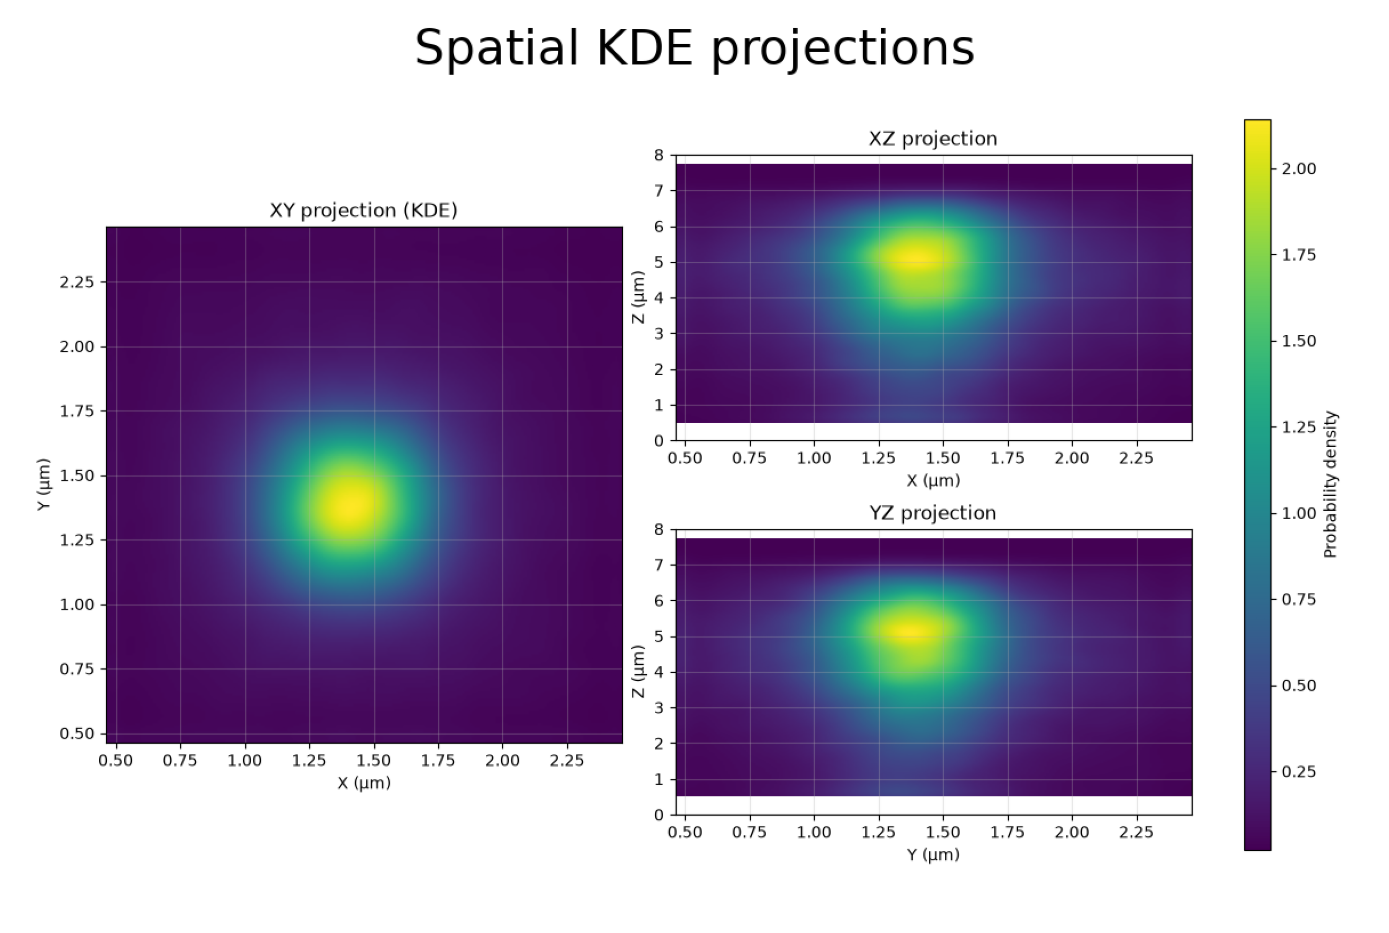

In [12]:
plot_file = f"{dest_path}/merged_traces_filtered_cleaned_kde_projections.png" # convert to um to display !!
img = mpimg.imread(plot_file)
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

This figure shows **kernel density estimation (KDE)** heatmaps of all spot positions projected onto three planes:

- **XY projection** (left): Top-down view of the sample. Bright regions = high spot density.
- **XZ projection** (top-right): Side view along Y. Shows the Z range where spots are concentrated.
- **YZ projection** (bottom-right): Side view along X.

**How this helps for filtering:**
- The **XZ** and **YZ** panels reveal the usable Z range. If spots concentrate between Z = 3 and Z = 11 µm,
  you can set `--z_min 3.0 --z_max 11.0` in Tutorial 3 to remove out-of-focus outliers.
- If the **XY** panel shows spots concentrated in a sub-region, you could use
  `--x_min` / `--x_max` / `--y_min` / `--y_max` to exclude border artifacts.
- A uniform XY distribution is normal; clusters may indicate imaging artifacts or biological structure.

## Step 7: Using QC Insights for Filtering

From the QC plots above, you can extract key metrics to guide filtering in Tutorial 3:

| Plot | What to Look For | Filter Option |
|------|------------------|---------------|
| Barcode Detection | Barcodes with very low median | `--remove_barcode` |
| Trace Statistics | N_barcodes median | `--n_barcodes` |
| Trace Statistics | N_repeated_barcodes > 0 | `--clean_spots` (Tutorial 4) |
| KDE Projections | Z range with spot concentration | `--z_min` / `--z_max` |
| KDE Projections | XY border artifacts | `--x_min` / `--y_max` etc. |

## Summary

Quality control revealed important characteristics of your merged dataset:

- **Trace completeness** — How many barcodes detected per trace
- **Barcode reliability** — Detection consistency for each barcode
- **Spatial distribution** — Where spots concentrate in X, Y, Z (KDE projections)
- **Neighbor spacing** — Distance characteristics (ΔX, ΔY, ΔZ)
- **Duplicate barcodes** — Repetition patterns across traces

**Next:** [Tutorial 3 — Filter Traces](tutorial_03_filter_thresholds.ipynb) using insights from these QC metrics